## Analyzing Multiple Completed Simulations
Dan Chen, Summer 2026

### Imports

In [1]:
# === IMPORTS ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import matplotlib.patheffects as path_effects

from astropy import units as u
from pathlib import Path
from collections import defaultdict
from fractions import Fraction
from functools import reduce

import mmr_id
import rebound_sims as reb_sims
from param_grid_plots import plot_param_grid_multi

import warnings
warnings.filterwarnings('ignore')

from helpers import plot_prettier_lite
plot_prettier_lite(dpi=110)

# === UNIT CONVERSIONS ===
AU = u.AU.to(u.cm)    
G = 4*np.pi**2 # in yr, AU, Msun
Msun = u.Msun.to(u.g) 
yr = u.yr.to(u.s)    
r_earth = u.earthRad.to(u.AU)
m_earth = u.Mearth.to(u.Msun)
r_sun = u.Rsun.to(u.AU) 

### Obtain simulation summary outcomes (survival, resonance, libration, accretion)

In [38]:
# First-order resonance classes (up to 7:6)
def classify_resonance(P_ratio, librates):
    """Classify first-order resonances of simulations up to 7:6. 
    If planets are not librating, the result will be "not in resonance".
    If planets are in higher-order or higher-index resonance, the result
    will be "other".


    Args:
        P_ratio (float): (Assigned) period ratio.
        librates (bool): Whether resonant angle librates.

    Returns:
        Classification of the resonance.
    """    


    if not librates or np.isnan(P_ratio):
        return "not in resonance"

    resonances = {
        "2:1": 2/1,
        "3:2": 3/2,
        "4:3": 4/3,
        "5:4": 5/4,
        "6:5": 6/5,
        "7:6": 7/6
    }

    for name, ratio in resonances.items():
        if P_ratio == ratio:
            return name

    return "other"

# P ratios, libration, and Delta between planets
def get_planet_outcomes(dataset_id, sim_ids, pomega='mixed', amp_threshold=90):
    rows = []
    base_dir = Path.cwd()
    for sim_id in sim_ids:
        file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"
        
        try:
            saved_sim = reb_sims.load_simulation_run(file_path)
        except FileNotFoundError:
            continue

        sim_data, metadata = saved_sim
        
        # Check planet survival
        alive_planets = []
        for name in ['planet b', 'planet c', 'planet d'][:metadata['num_pl']]:
            if not np.isnan(sim_data[name]['a'].iloc[-1]):
                alive_planets.append(name)

        # Check both pairs if all planets are alive
        if len(alive_planets) == 3:
            c = alive_planets[1]; d = alive_planets[2]
            
            # Get P_ratios by direct division
            true_outer_P_ratio = sim_data[d]['P'].iloc[-1]/sim_data[c]['P'].iloc[-1]
            
            # Swap planets if inner became outer
            if true_outer_P_ratio < 1:
                c, d = d, c
                true_outer_P_ratio = 1/true_outer_P_ratio
            
            # Check Delta (find p, q such that Delta is closest to 0)
            outer_best = mmr_id.find_best_twoBR_pq(metadata['m_star'], sim_data[c], sim_data[d])
            outer_P_ratio = outer_best[0]/outer_best[1]
            outer_Delta = true_outer_P_ratio/outer_P_ratio - 1
            
            # Check libration of 2BR angle
            outer_librates = (mmr_id.check_resonance(metadata['m_star'], sim_data[c], sim_data[d], pomega=pomega, N=25, amp_threshold=amp_threshold) != (0,0))
        
        else:
            outer_P_ratio = np.nan
            true_outer_P_ratio = np.nan
            outer_Delta = np.nan
            outer_librates = False
        
        # Check ratio of remaining pair, call it inner pair
        if len(alive_planets) >=2:
            b = alive_planets[0]; c = alive_planets[1] # this will be the right pair regardless
                
            # Get P_ratios by direct division
            true_inner_P_ratio = sim_data[c]['P'].iloc[-1]/sim_data[b]['P'].iloc[-1]
            
            # Swap planets if inner became outer
            if true_inner_P_ratio < 1:
                b, c = c, b
                true_inner_P_ratio = 1/true_inner_P_ratio
                
            # Check Delta (find p, q such that Delta is closest to 0)
            inner_best = mmr_id.find_best_twoBR_pq(metadata['m_star'], sim_data[b], sim_data[c])
            inner_P_ratio = inner_best[0]/inner_best[1]
            inner_Delta = true_inner_P_ratio/inner_P_ratio - 1
            
            # Check libration of 2BR angle
            inner_librates = (mmr_id.check_resonance(metadata['m_star'], sim_data[b], sim_data[c], pomega=pomega, amp_threshold=amp_threshold) != (0,0))

        else:
            inner_P_ratio = np.nan
            true_inner_P_ratio = np.nan
            inner_Delta = np.nan
            inner_librates = False
        
        if len(alive_planets) >= 1:
            m_pl = metadata['m_vals'][0]
            a = 0.65
            P = a**(3/2) # for M = 1
            Sigma = metadata['Sigma_1au']*(AU**2 / Msun) * a**-metadata['alpha']
            h = metadata['h_1au'] * a**metadata['beta']
            tau_a = 1/(2.7+1.1*metadata['alpha']) / m_pl / (Sigma * a**2) * h**2 / (2*np.pi / P) # at 0.65 AU
            log_tau_Omega = np.log10(tau_a * 2*np.pi / (a**(3/2))) # at 0.65 AU
            
            chi_a = 1 / (2.7 + 1.1 * metadata['alpha'])
            chi_e = 1 / 0.780
            log_K2 = np.log10(chi_a/chi_e * h**-2) # for inner ptsml and outer planet
        else:
            tau_a = np.nan
            log_tau_Omega = np.nan
            log_K2 = np.nan

        # Create df to store data
        Sigma_1au = metadata['Sigma_1au']
        h_1au = metadata['h_1au']
        
        rows.append({
            "sim_id": sim_id,
            "Sigma_1au": Sigma_1au,
            "h_1au": h_1au,
            "alive_planets": alive_planets,
            "inner_P_ratio": inner_P_ratio,
            "outer_P_ratio": outer_P_ratio,
            "true_inner_P_ratio": round(true_inner_P_ratio, 3),
            "true_outer_P_ratio": round(true_outer_P_ratio, 3),
            "inner_P_Delta (%)": round(inner_Delta*100, 1),
            "outer_P_Delta (%)": round(outer_Delta*100, 1),
            "inner_librates": inner_librates,
            "outer_librates": outer_librates,
            "inner_res_class": classify_resonance(inner_P_ratio, inner_librates),
            "outer_res_class": classify_resonance(outer_P_ratio, outer_librates),
            "pl_survived": len(alive_planets),
            "tau_a (kyr)": tau_a/1000,
            "log_tau_Omega": log_tau_Omega,
            "log_K2": log_K2
        })
        
    outcomes = pd.DataFrame(rows)
    return outcomes

# Sigma_1au, h_1au, log_tau_Omega, log_K2
def disk_params(dataset_id, sim_ids):
    rows = []
    base_dir = Path.cwd()
    for sim_id in sim_ids:
        file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"
        
        try:
            saved_sim = reb_sims.load_simulation_run(file_path)
        except FileNotFoundError:
            continue

        sim_data, metadata = saved_sim
        
        # Get tau_a_Omega and K2
        m_pl = metadata['m_vals'][0]
        m_em = metadata['m_em'] * m_earth
        a1 = 0.5 # middle of disk
        P1 = a1**(3/2) # for M = 1
        P2 = P1#*2 # or whatever ratio
        a2 = P2**(2/3)
        
        Sigma1 = metadata['Sigma_1au']*(AU**2 / Msun) * a1**-metadata['alpha']
        h1 = metadata['h_1au'] * a1**metadata['beta']
        Sigma2 = metadata['Sigma_1au']*(AU**2 / Msun) * a2**-metadata['alpha']
        h2 = metadata['h_1au'] * a2**metadata['beta']

        tau_a1 = 1/(2.7+1.1*metadata['alpha']) / m_em / (Sigma1 * a1**2) * h1**2 / (2*np.pi / P1) 
        tau_a2 = 1/(2.7+1.1*metadata['alpha']) / m_pl / (Sigma2 * a2**2) * h2**2 / (2*np.pi / P2) 
        tau_a = (tau_a2**(-1)-tau_a1**(-1))**(-1)
        
        log_tau_Omega = np.log10(tau_a * 2*np.pi / (a1**(3/2))) 
        
        chi_a = 1 / (2.7 + 1.1 * metadata['alpha'])
        chi_e = 1 / 0.780
        tau_e2 = chi_e/chi_a * h2**2 * tau_a2
        log_K2 = np.log10(tau_a / tau_e2)
        
        rows.append({
            "sim_id": sim_id,
            "Sigma_1au": metadata['Sigma_1au'],
            "h_1au": metadata['h_1au'],
            "tau_a (kyr)": tau_a/1000,
            "log_tau_Omega": round(log_tau_Omega, 2), # prevent errors in plotting
            "log_K2": round(log_K2, 2)
        })
    
    outcomes = pd.DataFrame(rows)
    return outcomes
        
# P ratio, libration, and Delta between one planet and one embryo (unused)
def pl_em_res(dataset_id, sim_ids, pomega='mixed', amp_threshold=90, snapshot=-1):
    rows = []
    base_dir = Path.cwd()
    for sim_id in sim_ids:
        file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"
        
        try:
            saved_sim = reb_sims.load_simulation_run(file_path)
        except FileNotFoundError:
            continue

        sim_data, metadata = saved_sim

        # find alive embryos
        alive_embryos = []
        for name in [f"embryo {i}" for i in range(metadata['num_em'])]:
            if not np.isnan(sim_data[name]['a'].iloc[snapshot]):
                alive_embryos.append(name)
                
        if len(alive_embryos) >= 1:
            for embryo_name in alive_embryos:
                b = embryo_name
                c = 'planet c'

            # Get P_ratios by direct division
            true_inner_P_ratio = sim_data[c]['P'].iloc[snapshot]/sim_data[b]['P'].iloc[snapshot]
            
            # Don't consider embryos outside of planet c's orbit
            if true_inner_P_ratio < 1:
                continue
                    
            # Check libration of 2BR angle
            inner_librates = (mmr_id.check_resonance(metadata['m_star'], sim_data[b], sim_data[c], pomega=pomega, amp_threshold=amp_threshold) != (0,0))
            if inner_librates:
                resonant_embryos += 1
        else:
            resonant_embryos = 0
        
        rows.append({
            "sim_id": sim_id,
            "resonant_embryos": resonant_embryos     
        })
        
    outcomes = pd.DataFrame(rows)
    return outcomes

# Find embryos AND planetesimals between b and c; detect resonance with inner planet
def embryos_between_planets(dataset_id, sim_ids, inner='planet b', outer='planet c', N=15, amp_threshold=90, snapshot=-1):
    rows = []
    base_dir = Path.cwd()
    for sim_id in sim_ids:
        file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"
        
        try:
            saved_sim = reb_sims.load_simulation_run(file_path)
        except FileNotFoundError:
            continue

        sim_data, metadata = saved_sim
    
        a_inner = sim_data[inner]["a"].iloc[-1]
        a_outer = sim_data[outer]["a"].iloc[-1]
        
        inside_found = 0
        inside_names = []

        for name, df in sim_data.items():
            if not (
                name.startswith("embryo")
                or name.startswith("ptsml")
            ):
                continue

            a_em = df["a"].iloc[snapshot]

            if np.isnan(a_em):
                continue

            if a_inner <= a_em <= a_outer:
                inside_found += 1
                inside_names.append(name)
        
        b_resonant_embryos = 0
        b_resonant_names = []
        c_resonant_embryos = 0
        c_resonant_names = []
        
        if inside_found >= 1:
            for embryo_name in inside_names:
                
                # Check libration of 2BR angle of inner pair
                inner_librates = (mmr_id.check_resonance(metadata['m_star'], sim_data[inner], sim_data[embryo_name], N=N, pomega='mixed', amp_threshold=amp_threshold) != (0,0))
                if inner_librates:
                    b_resonant_names.append(embryo_name)
                    b_resonant_embryos += 1
                
                # Check libration of 2BR angle of outer pair
                outer_librates = (mmr_id.check_resonance(metadata['m_star'], sim_data[embryo_name], sim_data[outer], N=N, pomega='mixed', amp_threshold=amp_threshold) != (0,0))
                if outer_librates:
                    c_resonant_names.append(embryo_name)
                    c_resonant_embryos += 1
        
        rows.append({
            "sim_id": sim_id,
            "embryos_inside": inside_found,
            "inside_names": inside_names,
            "b_resonant_embryos": b_resonant_embryos,
            "b_resonant_names": b_resonant_names,
            "c_resonant_embryos": c_resonant_embryos,
            "c_resonant_names": c_resonant_names,
        })
    
    outcomes = pd.DataFrame(rows)
    return outcomes

# Embryo mass
def additional_params(dataset_id, sim_ids):
    rows = []
    base_dir = Path.cwd()
    for sim_id in sim_ids:
        file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"
        
        try:
            saved_sim = reb_sims.load_simulation_run(file_path)
        except FileNotFoundError:
            continue

        sim_data, metadata = saved_sim
        
        rows.append({
            "sim_id": sim_id,
            "m_em": metadata['m_em']
        })
    
    outcomes = pd.DataFrame(rows)
    return outcomes

# Obtain and clean up collision log
def get_collision_log(metadata, max_time=None):
    """Collects collision log and converts to pd.DataFrame for later use.

    Args:
        metadata (dict): Metadata from simulation; typically comes from saved_sim[1].
        max_time (float, optional)

    Returns:
        pd.DataFrame: collision_df
    """    
    collision_df = pd.DataFrame(metadata["collision_log"])
    collision_df["time"] = collision_df["time"] / 1000  # kyr

    if max_time is not None:
        collision_df = collision_df[collision_df["time"] <= max_time]

    collision_df["time"] = collision_df["time"].round(2)
    collision_df = collision_df.rename(columns={"time": "time (kyr)"})

    collision_df["victim mass"] = (collision_df["victim mass"] / m_earth).round(4)
    collision_df = collision_df.rename(columns={"victim mass": "victim mass (m_earth)"})

    return collision_df.sort_values("time (kyr)")

# Obtain and clean up particle fates
def get_particle_fates(metadata, max_time=None):
    collision_df = get_collision_log(metadata, max_time)

    fates = {name: "alive" for name in metadata["particle_fate"]}

    for _, row in collision_df.iterrows():
        fates[row["victim"]] = "collided"

    return pd.Series(fates, name="outcome").sort_index().to_frame()

# Summarize accretion data
def summarize_accretion(metadata, collision_df, fates_df, percent=True):
    """Summarizes accretion information.

    Args:
        collision_df (pandas.DataFrame): DataFrame of collision log.
        percent (bool, optional): Whether to show fraction as percentage. 
            Defaults to True.

    Returns:
        pandas.DataFrame: Dataframe containing accretion summary.
    """    
    children = defaultdict(list)

    for _, row in collision_df.iterrows():
        children[row["survivor"]].append(row["victim"])

    def get_all_accreted(body):
        """Returns every particle ultimately accreted by body."""
        accreted = []

        for child in children.get(body, []):
            accreted.append(child)
            accreted.extend(get_all_accreted(child))

        return accreted

    alive_particles = [
        name
        for name, outcome in fates_df["outcome"].items()
        if outcome == "alive"
    ]

    rows = []

    for particle in alive_particles:
        accreted = get_all_accreted(particle)

        n_embryos = sum("embryo" in p for p in accreted)
        n_ptsmls = sum("ptsml" in p for p in accreted)

        rows.append({
            "particle": particle,
            "n_ems": n_embryos,
            "n_ptsmls": n_ptsmls,
            "embryo %": n_embryos / metadata['num_em'] if metadata["num_em"] != 0 else 0,
            "ptsml %": n_ptsmls / metadata['num_ptsml'] if metadata["num_ptsml"] != 0 else 0,
        })

    alive_accretion_df = (pd.DataFrame(rows).set_index("particle").sort_index())

    # Keep only particles that actually accreted something
    alive_accretion_df = alive_accretion_df[
        alive_accretion_df["n_ems"] + alive_accretion_df["n_ptsmls"] > 0
    ].sort_values('n_ptsmls', ascending=False) # & sort by ptsmls accreted

    # Remaining unaccreted bodies
    n_alive_ems = metadata['num_em'] - alive_accretion_df["n_ems"].sum()
    n_alive_ptsmls = metadata['num_ptsml'] - alive_accretion_df["n_ptsmls"].sum()

    alive_accretion_df.loc["Survived"] = {
        "n_ems": n_alive_ems,
        "n_ptsmls": n_alive_ptsmls,
        "embryo %": n_alive_ems / metadata['num_em'] if metadata["num_em"] != 0 else 0,
        "ptsml %": n_alive_ptsmls / metadata['num_ptsml']if metadata["num_ptsml"] != 0 else 0,
    }

    if percent:
        # Convert to %
        alive_accretion_df["embryo %"] = (alive_accretion_df["embryo %"]*100).round(2)
        alive_accretion_df["ptsml %"] = (alive_accretion_df["ptsml %"]*100).round(2)

    return alive_accretion_df

# Planetesimal (and embryo) accretion data
def get_ptsml_outcomes(dataset_id, sim_ids, snapshot=None):
    rows = []
    
    for sim_id in sim_ids:
        base_dir = Path.cwd()
        file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"
        
        try:
            saved_sim = reb_sims.load_simulation_run(file_path)
        except FileNotFoundError:
            # print(f"Sim {sim_id} not found")
            continue
        
        sim_data, metadata = saved_sim
        
        # Get survival fraction
        if snapshot:
            snapshot_time = sim_data["planet b"]["time"].iloc[snapshot] / 1000  # kyr
        else:
            snapshot_time = None
        # print(f"Processing Sim {sim_id}", end='\r', flush=True)
        
        if not metadata['collision_log']: # no collisions occurred
            em_surv_rate, ptsml_surv_rate, ejec_rate = 100, 100, 0
        else:
            collision_df = get_collision_log(metadata, snapshot_time)
            fates_df = get_particle_fates(metadata, snapshot_time)
            summary = summarize_accretion(metadata, collision_df, fates_df)
            em_surv_rate = summary['embryo %']['Survived']
            ptsml_surv_rate = summary['ptsml %']['Survived']
            
            # Get ejection fraction (both embryos and planetesimals; ejected due to being removed from sim)
            ejec_rate = fates_df['outcome'].str.contains('ejected').sum()/len(fates_df)

        # Find median of semimajor axes of embryos
        em_a_finals = [sim_data[f'embryo {i}']["a"].iloc[-1] for i in range(metadata['num_em'])]
        em_a_med = np.nanmedian(em_a_finals)
        
        # Find median e of embryos
        em_e_finals = [sim_data[f'embryo {i}']["e"].iloc[-1] for i in range(metadata['num_em'])]
        em_e_med = np.nanmedian(em_e_finals)

        # Find median of semimajor axes of ptsmls
        ptsml_a_finals = [sim_data[f'ptsml {i}']["a"].iloc[-1] for i in range(metadata['num_ptsml'])]
        ptsml_a_med = np.nanmedian(ptsml_a_finals)
        
        # Find median e of ptsmls
        ptsml_e_finals = [sim_data[f'ptsml {i}']["e"].iloc[-1] for i in range(metadata['num_ptsml'])]
        ptsml_e_med = np.nanmedian(ptsml_e_finals)

        rows.append({
            "sim_id": sim_id,
            "em_surv_rate (%)": em_surv_rate,
            "ptsml_surv_rate (%)": ptsml_surv_rate,
            "ejec_rate (%)": ejec_rate,
            "ptsml_a_median": ptsml_a_med,
            "ptsml_e_median": ptsml_e_med,
            "em_a_median": em_a_med,
            "em_e_median": em_e_med,
        })
        
    outcomes = pd.DataFrame(rows)
    return outcomes

In [39]:
dataset_id = 2
sim_ids = list(range(10800))
snapshot = -1

disk_df = disk_params(dataset_id=dataset_id, sim_ids=sim_ids)
print("Disk df collected")
embryo_df = embryos_between_planets(dataset_id=dataset_id, sim_ids=sim_ids, inner='planet b', outer='planet c', amp_threshold=120, snapshot=snapshot)
print("Embryos df collected")
additional_df = additional_params(dataset_id=dataset_id, sim_ids=sim_ids)
print("Additional df collected")
accretion_df = get_ptsml_outcomes(dataset_id=dataset_id, sim_ids=sim_ids, snapshot=snapshot)
print("Accretion df collected")

merged_outcomes = reduce(lambda left, right: pd.merge(left, right, on='sim_id', how='outer'), [disk_df, embryo_df, additional_df, accretion_df])

# Drop unneeded columns
merged_outcomes = merged_outcomes.drop(columns=[
                                                'ptsml_surv_rate (%)', 
                                                'ejec_rate (%)', 
                                                'ptsml_a_median', 
                                                'ptsml_e_median'
                                            ])

merged_outcomes.to_hdf(f"dfs/outcomes{dataset_id}_{snapshot}.h5", key="df", mode="w") # Save to disk

Disk df collected
Embryos df collected
Additional df collected
Accretion df collected


In [17]:
outcomes = pd.read_hdf(f"dfs/outcomes{dataset_id}_{snapshot}.h5", key="df") # Load data
outcomes
# outcomes[outcomes['embryos_inside'] >= 3]

,sim_id,Sigma_1au,h_1au,tau_a (kyr),log_tau_Omega,log_K2,embryos_inside,inside_names,b_resonant_embryos,b_resonant_names,c_resonant_embryos,c_resonant_names,m_em,em_surv_rate (%),em_a_median,em_e_median
0,0,170.000000,0.010000,10.306986,5.26,3.31,0,[],0,[],0,[],1.000000e-06,40.0,NaN,NaN
1,1,199.257391,0.010000,8.793589,5.19,3.31,0,[],0,[],0,[],1.000000e-06,25.0,NaN,NaN
2,2,233.550045,0.010000,7.502408,5.12,3.31,0,[],0,[],0,[],1.000000e-06,40.0,NaN,NaN
3,3,273.744545,0.010000,6.400813,5.06,3.31,0,[],0,[],0,[],1.000000e-06,45.0,NaN,NaN
4,4,320.856610,0.010000,5.460968,4.99,3.31,0,[],0,[],0,[],1.000000e-06,75.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6571,10704,7684.601216,0.078805,14.159981,5.40,1.52,1,[embryo 0],1,[embryo 0],0,[],5.000000e-07,30.0,0.590488,0.005260
6572,10705,9007.138741,0.078805,12.080841,5.33,1.52,1,[embryo 0],0,[],0,[],5.000000e-07,30.0,0.596046,0.004712
6573,10706,10557.288012,0.078805,10.306985,5.26,1.52,3,"[embryo 1, embryo 2, embryo 3]",3,"[embryo 1, embryo 2, embryo 3]",0,[],5.000000e-07,20.0,0.117350,0.080762
6574,10707,12374.221535,0.078805,8.793588,5.19,1.52,2,"[embryo 1, embryo 3]",2,"[embryo 1, embryo 3]",0,[],5.000000e-07,30.0,0.535658,0.005439


### Plot parameter grid (2 parameters)

In [ ]:
%matplotlib widget
plot_prettier_lite(dpi=400)

def plot_param_grid_map(outcomes, value_col, label, x_col="Sigma_1au", y_col="h_1au", nbins=None,
                         cmap='viridis', vmin=None, vmax=None, exp=False, log_cmap=False,
                         show_text=True, show_libration=False, show_Delta=False, show_box=False,
                         black_threshold=0.5, h_cut=None, discrete_ratios=True):

    # ratios = [2/1, 5/3, 3/2, 4/3, 5/4, 6/5, 7/6, 1, 8/7, 11/9, 11/8, 9/7, 7/5, 8/5, 7/4, 9/8, 10/9, 11/10, 12/11, 13/12, 14/13, 13/11, 13/10]
    ratios = [2/1, 3/2, 4/3, 5/4, 6/5, 7/6, 8/7, 5/3, 7/5, 9/7, 11/9, 8/5, 11/8] # DS7
    ratios = [2/1, 3/2, 4/3, 5/4, 6/5, 7/6, 8/7, 5/3, 7/5, 9/7, 7/4] # DS6
 
    # Bin first
    if x_col == "log_tau_Omega":
 
        outcomes = outcomes.copy()
 
        bins = np.linspace(
            outcomes[x_col].min(),
            outcomes[x_col].max(),
            nbins
        )
 
        outcomes["log_tau_Omega_bin"] = pd.cut(
            outcomes[x_col],
            bins=bins,
            labels=False,
            include_lowest=True
        )
 
        x_labels = (
            outcomes
            .groupby("log_tau_Omega_bin", observed=True)["log_tau_Omega"]
            .mean()
            .values
        )
 
        x_col = "log_tau_Omega_bin"
 
    # Now compute unique grid values AFTER binning
    x_vals = np.sort(outcomes[x_col].dropna().unique())
    y_vals = np.sort(outcomes[y_col].unique())
 
    if h_cut:
        y_vals = y_vals[y_vals <= h_cut]
 
    # Grid
    grid = (
        outcomes
        .pivot_table(
            index=x_col,
            columns=y_col,
            values=value_col,
            aggfunc=lambda x: x.mode().iloc[0] if len(x.mode()) else np.nan
        )
        .reindex(index=x_vals,
                 columns=y_vals)
    )
 
    values = grid.values
 
    # Libration and Delta grid
    if value_col == "inner_P_ratio":
        if show_libration:
            libration_grid = (
                outcomes
                .pivot_table(
                    index=x_col,
                    columns=y_col,
                    values="inner_librates",
                    aggfunc="mean"
                )
                .reindex(index=x_vals, columns=y_vals)
            )
        else:
            libration_grid = None
        if show_Delta:
            Delta_grid = (
                outcomes
                .pivot_table(
                    index=x_col,
                    columns=y_col,
                    values="inner_P_Delta (%)",
                    aggfunc="mean"
                )
                .reindex(index=x_vals, columns=y_vals)
            )
        else:
            Delta_grid = None
    elif value_col == "outer_P_ratio":
        if show_libration:
            libration_grid = (
                outcomes
                .pivot(index=x_col, columns=y_col, values="outer_librates")
                .reindex(index=x_vals, columns=y_vals)
            )
        else:
            libration_grid = None
        if show_Delta:
            Delta_grid = (
                outcomes
                .pivot(index=x_col, columns=y_col, values="outer_P_Delta (%)")
                .reindex(index=x_vals, columns=y_vals)
            )
        else:
            Delta_grid = None
    else:
        libration_grid = None
        Delta_grid = None
 
    # Edges
    x_edges = np.empty(len(x_vals)+1)
    if x_col == 'Sigma_1au':
        x_edges[1:-1] = np.sqrt(x_vals[:-1] * x_vals[1:])
        x_edges[0] = x_vals[0]**2 / x_edges[1]
        x_edges[-1] = x_vals[-1]**2 / x_edges[-2]
    elif x_col == "log_tau_Omega_bin":
 
        x_edges[1:-1] = (
            np.arange(len(x_vals)-1) + 0.5
        )
 
        x_edges[0] = -0.5
        x_edges[-1] = len(x_vals)-0.5
 
    y_edges = np.empty(len(y_vals)+1)
    y_edges[1:-1] = np.sqrt(y_vals[:-1] * y_vals[1:])
    y_edges[0] = y_vals[0]**2 / y_edges[1]
    y_edges[-1] = y_vals[-1]**2 / y_edges[-2]
 
    # Plotting
    fig, ax = plt.subplots(figsize=(5,4))
 
    ratios_sorted = None  # populated only in the discrete_ratios branch, needed later for colorbar ticks
    
    show_other = False
    show_na = True
    
    if 'survived' in value_col:
        cmap = mcolors.ListedColormap(["#482173", "#2E6F8E", "#29AF7F"])
        norm = mcolors.BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap.N)
        color_values = values
    elif discrete_ratios and 'ratio' in value_col:
        # Bin each value into: index of matching named resonance, or a trailing "other" bin.
        # Coloring is done on these integer bins, not on the raw ratio, so viridis assigns
        # one discrete color per named resonance instead of a continuous gradient.
        ratios_sorted = sorted(set(ratios))
        n_special = len(ratios_sorted)
        base = plt.get_cmap('viridis', n_special)
        color_list = [base(i) for i in range(n_special)] 
        if show_other:
            color_list += ['dimgray']  # unlisted ratio
        if show_na:
            color_list += ['lightgray']  # N/A

        cmap = mcolors.ListedColormap(color_list)
        norm = mcolors.BoundaryNorm(np.arange(-0.5, n_special + 0.5 + int(show_other) + int(show_na), 1), cmap.N)
 
        tol = 1e-4
        def _to_bin(v):
            if np.isnan(v):
                return np.nan
            for i, r in enumerate(ratios_sorted):
                if abs(v - r) < tol:
                    return i
            return n_special
        color_values = np.vectorize(_to_bin, otypes=[float])(values)
    else:
        cmap = plt.get_cmap(cmap).copy() # make a copy so we don't modify the global colormap
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax) if log_cmap else None
        color_values = values
 
    cmap.set_bad("lightgray")  # NaN cells (no pair found)
 
    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        color_values.T,
        cmap=cmap,
        norm=norm,
        shading="flat",
        vmin=None if norm is not None else vmin,
        vmax=None if norm is not None else vmax,
    )
 
    if x_col == "Sigma_1au":
        ax.set_xlabel(r"$\Sigma_{1\,\rm AU}\;(\mathrm{g\,cm^{-2}})$")
        ax.set_xscale("log")
        ax.set_xticklabels([f"{x:.0f}" for x in x_vals][1::3])
        ax.set_xticks(x_vals[1::3])
    elif x_col == "log_tau_Omega_bin":
 
        ax.set_xlabel(r"$\log_{10}(\tau_a\Omega)$")
        ax.set_xscale("linear")
 
        tick_idx = np.arange(len(x_labels))[::3]
 
        ax.set_xticks(tick_idx)
        ax.set_xticklabels(
            [f"{x:.1f}" for x in x_labels[::3]]
        )
 
    if y_col == "h_1au":
        ax.set_ylabel(r"$h_{1\,\rm AU}$")
        ax.set_yscale("log")
        ax.set_yticks(y_vals[1::3])
        ax.set_yticklabels([f"{y:.3f}" for y in y_vals][1::3])
    elif y_col == "log_K2":
        ax.set_ylabel(r"$\log \mathcal{K_2}$")
        ax.set_yscale("linear")
 
    ax.minorticks_off()
 
    # Cell text (values here are still the raw ratios/quantities, unaffected by color_values)
    if x_col == "log_tau_Omega_bin":
        x_plot_vals = np.arange(len(x_vals))
    else:
        x_plot_vals = x_vals
 
    for i, x in enumerate(x_plot_vals):
        for j, y in enumerate(y_vals):
 
            value = values[i, j]
            if np.isnan(value):
                continue
 
            color = "white"
            if value > black_threshold:
                color = "k"
 
            if exp:
                disp_value = f"{value:.1e}"
            elif 'survived' in value_col:
                disp_value = f"{value:.2g}"
            elif "%" in value_col:
                disp_value = f"{round(value)}%"
            elif "ratio" in value_col:
                frac = Fraction(value).limit_denominator()
                disp_value = f"{frac.numerator}:{frac.denominator}" if value in ratios else f"{value:.3f}"
            elif "kyr" in value_col:
                disp_value = int(value)
            elif "id" in value_col:
                disp_value = int(value)
            else:
                disp_value = f"{value:.2f}"
 
            if show_text:
                text = ax.text(
                    x, y,
                    disp_value,
                    ha="center",
                    va="center",
                    fontsize=4,
                    weight='bold',
                    color=color,
                    zorder=5
                )
 
                text.set_path_effects([
                    path_effects.withStroke(linewidth=0.4, foreground="black")
                ])
                if value > black_threshold:
                    text.set_path_effects([
                        path_effects.withStroke(linewidth=0.4, foreground="white")
                    ])
 
            if libration_grid is not None:
                if libration_grid.values[i, j]:
                    ax.annotate(
                        "L",
                        xy=(x, y),
                        xytext=(0, 1),
                        textcoords="offset points",
                        ha="center",
                        va="top",
                        fontsize=5,
                        color="C3",
                        fontweight="bold"
                    )
 
            if Delta_grid is not None:
                ax.annotate(
                    rf"$\Delta = {Delta_grid.values[i, j]}$%",
                    xy=(x, y),
                    xytext=(0, -5),
                    textcoords="offset points",
                    ha="center",
                    va="top",
                    fontsize=4,
                    color=color,
                    fontweight="bold"
                )
 
    cbar = fig.colorbar(mesh, ax=ax)
 
    cbar.set_label(label)
    if discrete_ratios and 'ratio' in value_col:
        n_special = len(ratios_sorted)
        tick_locs = list(range(n_special + int(show_other) + int(show_na)))
        tick_labels = [
            f"{Fraction(r).limit_denominator().numerator}:{Fraction(r).limit_denominator().denominator}"
            for r in ratios_sorted
        ]
        if show_other:
            tick_labels += ['other']
        if show_na:
            tick_labels += ['N/A']
            
        cbar.set_ticks(tick_locs, labels=tick_labels)
        cbar.ax.minorticks_off()
    elif 'ratio' in value_col:
        cbar.set_ticks(ratios[:8], labels=['2:1', '5:3', '3:2', '4:3', '5:4', '6:5', '7:6', '1:1'])
        cbar.ax.minorticks_off()
    elif 'survived' in value_col:
        cbar.set_ticks([1,2,3])
 
    if show_box:                # Bottom left corner
        rect = patches.Rectangle((200, 0.025), width=300, height=0.01, edgecolor='r', facecolor='none', linewidth=1, alpha=0.7, linestyle='dashed')
        ax.add_patch(rect)
 
    ax.tick_params(axis='both', direction='inout')
    cbar.ax.tick_params(direction='inout')
 
    plt.tight_layout()
    plt.show()

dataset_id = 6
snapshot = -1
outcomes = pd.read_hdf(f"dfs/planet_outcomes{dataset_id}.h5", key="df") # Load data

# plot_param_grid_map(outcomes, "pl_survived", "Number of planets remaining", vmin=1, show_text=True, show_box=False, black_threshold=3)
# plot_param_grid_map(outcomes, "true_inner_P_ratio", r"Inner pair period ratio ($P_c/P_b$)", x_col="log_tau_Omega", y_col="log_K2", vmin=1, vmax=2, show_text=True, show_libration=False, show_Delta=False, show_box=False, black_threshold=1.6, log_cmap=True)
plot_param_grid_map(outcomes, "inner_P_ratio", r"Inner pair period ratio ($P_c/P_b$)", vmin=1, vmax=2, show_text=False, show_libration=False, show_Delta=False, show_box=False, black_threshold=1.6, log_cmap=True)
# plot_param_grid_map(outcomes, "inner_P_ratio", r"Inner pair period ratio ($P_c/P_b$)", x_col="log_tau_Omega", y_col="log_K2", nbins=32, vmin=1, vmax=2, show_text=True, show_libration=False, show_Delta=False, show_box=False, black_threshold=1.6, log_cmap=True)
plot_param_grid_map(outcomes, "outer_P_ratio", r"Outer pair period ratio ($P_d/P_c$)", vmin=1, show_text=False, show_libration=False, show_box=False, black_threshold=1.6, log_cmap=True)
# plot_param_grid_map(outcomes, "tau_a (kyr)", r"$\tau_a$ (kyr)", cmap='coolwarm', log_cmap=True, black_threshold=0)

# plot_param_grid_map(outcomes, "log_tau_Omega", r"$\log \tau_a \Omega$", show_text=True, show_libration=False, show_Delta=False, show_box=False, black_threshold=1.6, log_cmap=True)
# plot_param_grid_map(outcomes, "log_K2", r"$\log K_2$",show_text=True, show_libration=False, show_Delta=False, show_box=False, black_threshold=1.6, log_cmap=True)
# plot_param_grid_map(outcomes, "sim_id", "Sim ID", nbins=32, black_threshold=200)

# plot_param_grid_map(outcomes, "surv_rate (%)", "Fraction of planetesimals remaining", x_col='log_tau_Omega', y_col='log_K2', nbins=50, cmap='inferno', show_text=False, black_threshold=0)
# plot_param_grid_map(outcomes, "ejec_rate (%)", "Fraction of planetesimals ejected (%)")
# plot_param_grid_map(outcomes, "ptsml a_median", "Median semi-major axis of surviving planetesimals", cmap='BuPu', black_threshold=0)
# plot_param_grid_map(outcomes, "ptsml e_median", "Median eccentricity of surviving planetesimals", cmap='BuPu', black_threshold=0)

### Plot parameter grid (3 parameters)

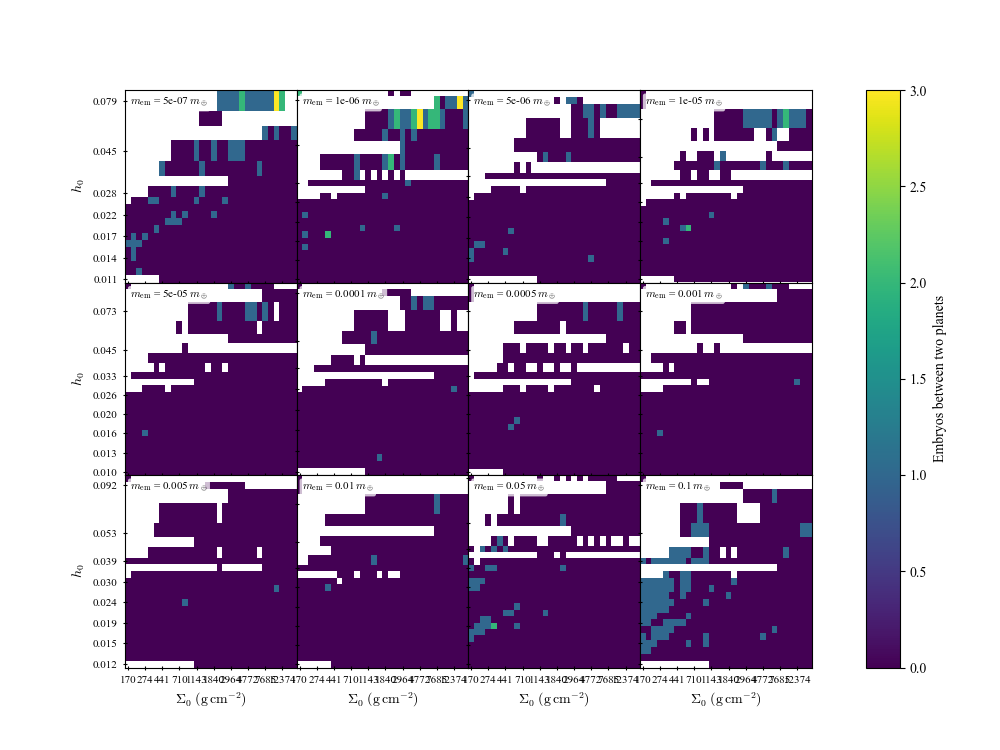

In [22]:
%matplotlib widget
dataset_id = 2
snapshot = -1
outcomes = pd.read_hdf(f"dfs/outcomes{dataset_id}_{snapshot}.h5", key="df") # Load data

outcomes = outcomes[outcomes['m_em'] <= 0.1] # this prevents the code from breaking
outcomes['scattered (%)'] = outcomes["em_surv_rate (%)"] - 100*outcomes["embryos_inside"]/6
outcomes['accreted (%)'] = 100 - outcomes["em_surv_rate (%)"]

ncols = 4
x_tick_step = 3
y_tick_step = 3

plot_param_grid_multi(outcomes, "embryos_inside", "Embryos between two planets", show_text=False, ncols=ncols, x_tick_step=x_tick_step, y_tick_step=y_tick_step)
# plot_param_grid_multi(outcomes, "em_surv_rate (%)", "Total embryos survived (%)", show_text=False, ncols=ncols, x_tick_step=x_tick_step, y_tick_step=y_tick_step)
# plot_param_grid_multi(outcomes, "b_resonant_embryos", "Embryos resonant with planet b", show_text=False, ncols=ncols, x_tick_step=x_tick_step, y_tick_step=y_tick_step)
# plot_param_grid_multi(outcomes, "scattered (%)", "Embryos scattered (%)", show_text=False, ncols=ncols, x_tick_step=x_tick_step, y_tick_step=y_tick_step)
# plot_param_grid_multi(outcomes, "accreted (%)", "Embryos accreted (%)", show_text=False, ncols=ncols, x_tick_step=x_tick_step, y_tick_step=y_tick_step)
# plot_param_grid_multi(outcomes, "sim_id", "Sim ID", ncols=ncols, x_tick_step=x_tick_step, y_tick_step=y_tick_step)

### Plot zoomed-in parameter space with binned samples

In [ ]:
def plot_binned_param_map(outcomes, value_col, label, Sigma_range=None, h_range=None, nbins=10, cmap="viridis", vmin=None, vmax=None, log_cmap=False, black_threshold=None, show_text=True, scatter=True, show_sim_id=False):

    # Parameter space limits
    if Sigma_range is None:
        Sigma_range = (
            outcomes["Sigma_1au"].min(),
            outcomes["Sigma_1au"].max()
        )

    if h_range is None:
        h_range = (
            outcomes["h_1au"].min(),
            outcomes["h_1au"].max()
        )

    # Log-spaced bin edges
    Sigma_edges = np.logspace(
        np.log10(Sigma_range[0]),
        np.log10(Sigma_range[1]),
        nbins + 1
    )

    h_edges = np.logspace(
        np.log10(h_range[0]),
        np.log10(h_range[1]),
        nbins + 1
    )

    # Bin centers for text
    Sigma_centers = np.sqrt(Sigma_edges[:-1] * Sigma_edges[1:])
    h_centers = np.sqrt(h_edges[:-1] * h_edges[1:])

    # Assign simulations to bins

    xbin = np.digitize(
        outcomes["Sigma_1au"],
        Sigma_edges
    ) - 1

    ybin = np.digitize(
        outcomes["h_1au"],
        h_edges
    ) - 1

    outcomes_binned = outcomes.copy()
    outcomes_binned["xbin"] = xbin
    outcomes_binned["ybin"] = ybin

    # Remove points outside edges
    outcomes_binned = outcomes_binned[
        (outcomes_binned["xbin"] >= 0)
        & (outcomes_binned["xbin"] < nbins)
        & (outcomes_binned["ybin"] >= 0)
        & (outcomes_binned["ybin"] < nbins)
    ]

    # Median value in each bin
    median_grid = np.full((nbins, nbins), np.nan)

    for i in range(nbins):
        for j in range(nbins):

            subset = outcomes_binned[
                (outcomes_binned["xbin"] == i)
                & (outcomes_binned["ybin"] == j)
            ]

            if len(subset) > 0:                                                              # Could also use nanmean
                median_grid[i, j] = np.nan if np.isnan(subset[value_col]).mean() > 0.5 else np.nanmedian(subset[value_col])

    # Plot
    fig, ax = plt.subplots(figsize=(5, 4))

    if 'survived' in value_col:
        cmap = mcolors.ListedColormap(["#482173", "#2E6F8E", "#29AF7F"])
        cmap.set_bad("lightgray")
        norm = mcolors.BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap.N)
    else:
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax) if log_cmap else None

    mesh = ax.pcolormesh(
        Sigma_edges,
        h_edges,
        median_grid.T,
        cmap=cmap,
        shading="flat",
        norm=norm,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(
        r"$\Sigma_{1\,\rm AU}\;(\mathrm{g\,cm^{-2}})$"
    )
    ax.set_ylabel(
        r"$h_{1\,\rm AU}$"
    )
    
    ax.set_xticks(Sigma_centers)
    ax.set_yticks(h_centers)

    ax.set_xticklabels([f"{x:.0f}" for x in Sigma_centers])
    ax.set_yticklabels([f"{y:.3f}" for y in h_centers])

    ax.minorticks_off()

     # Scatter
    if scatter:
        
        if 'outer' in value_col:
            x_mask = outcomes["outer_P_ratio"].isna()
        elif 'inner' in value_col:
            x_mask = outcomes["inner_P_ratio"].isna()
        else:
            x_mask = np.full(len(outcomes), False)
            
        ax.scatter(
            outcomes.loc[x_mask, "Sigma_1au"],
            outcomes.loc[x_mask, "h_1au"],
            s=2,
            color="red",
            marker="x",
            linewidths=0.5,
            zorder=4,
            alpha=0.8
        )
        
        ax.scatter(
            outcomes.loc[~x_mask, "Sigma_1au"],
            outcomes.loc[~x_mask, "h_1au"],
            s=2,
            alpha=0.5,
            color="k",
            edgecolors="none",
            zorder=3,
            marker="D"
        )

        # Show sim_id's
        if show_sim_id:
            for _, row in outcomes.iterrows():
                ax.annotate(
                    str(int(row["sim_id"])),
                    xy=(row["Sigma_1au"], row["h_1au"]),
                    xytext=(0, -1),
                    textcoords="offset points",
                    ha="center",
                    va="top",
                    fontsize=4,
                    color="k",
                    zorder=4
                )
        
    # Cell text
    ratios = [2/1, 5/3, 3/2, 7/5, 4/3, 5/4, 6/5, 7/6, 8/7, 1]
    if show_text:

        for i, x in enumerate(Sigma_centers):
            for j, y in enumerate(h_centers):

                value = median_grid[i, j]

                if np.isnan(value):
                    continue
                
                color = "white"
                
                if value > black_threshold:
                    color = "k"

                if "ratio" in value_col:
                    frac = Fraction(value).limit_denominator()
                    disp_value = f"{frac.numerator}:{frac.denominator}" if value in ratios else f"{value:.3f}"
                elif "%" in value_col:
                    disp_value = f"{value:.2g}"
                elif "survived" in value_col:
                    disp_value = f"{value:.2g}"
                else:
                    disp_value = f"{value:.2g}"

                text = ax.text(
                    x,
                    y,
                    disp_value,
                    ha="center",
                    va="center",
                    fontsize=6,
                    color=color,
                    zorder=5
                )
                
                text.set_path_effects([
                    path_effects.withStroke(linewidth=0.4, foreground="black")
                ])
                if value > black_threshold:
                    text.set_path_effects([
                        path_effects.withStroke(linewidth=0.4, foreground="white")
                    ])

    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(label)
    
    ax.tick_params(axis='both', direction='inout')
    cbar.ax.tick_params(direction='inout')
    
    if 'ratio' in value_col:
        cbar.set_ticks(ratios, labels=['2:1', '5:3', '3:2', '7:5', '4:3', '5:4', '6:5', '7:6', '8:7', '1:1'])
        cbar.ax.minorticks_off()

    plt.tight_layout()
    plt.show()
 
planet_outcomes = pd.read_hdf("dfs/planet_outcomes8_c.h5", key="df") # Load data
ptsml_outcomes = pd.read_hdf("dfs/ptsml_outcomes8.h5", key="df") # Load data
   
Sigma_range = (10**(454/145), 10**(517/145))
h_range=(10**(-437/290), 10**(-187/145))

plot_binned_param_map(planet_outcomes, 'pl_survived', "Number of planets remaining", Sigma_range, h_range, show_text=True, black_threshold=4)
plot_binned_param_map(planet_outcomes, 'inner_P_ratio', r"Inner pair period ratio ($P_c/P_b$)", Sigma_range, h_range, show_sim_id=False, black_threshold=1.6, vmin=1, vmax=2, log_cmap=True)
plot_binned_param_map(planet_outcomes, 'outer_P_ratio', r"Outer pair period ratio ($P_d/P_c$)", Sigma_range, h_range, show_sim_id=False, black_threshold=1.6, vmin=1, vmax=2, log_cmap=True)
plot_binned_param_map(ptsml_outcomes, 'surv_rate (%)', "Planetesimal survival rate (%)", Sigma_range, h_range, black_threshold=0, cmap='coolwarm')

### Extras

In [35]:
# Code for checking which simulations have not been done
base_dir = Path.cwd()
dataset_id = 2
missing = [
    sim_id
    for sim_id in range(10800)
    if not (base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5").exists()
]
print(f"{len(missing)} missing")
def format_ranges(nums):
    if not nums:
        return ""

    nums = sorted(nums)
    ranges = []

    start = end = nums[0]

    for n in nums[1:]:
        if n == end + 1:
            end = n
        else:
            if start == end:
                ranges.append(f"{start}")
            else:
                ranges.append(f"{start}-{end}")
            start = end = n

    # Add the last range
    if start == end:
        ranges.append(f"{start}")
    else:
        ranges.append(f"{start}-{end}")

    return ",".join(ranges)
print(format_ranges(missing))

4224 missing
390-393,396,420-431,450-451,480-487,491,493,495,497,499-543,570-647,660-669,690-761,780-863,871-885,887,890-971,1320,1350-1353,1359,1380-1403,1410-1412,1440-1447,1449,1451-1511,1530-1537,1560-1629,1636-1637,1643-1727,1740-1754,1756,1760-1769,1771-1835,2190,2220-2225,2227,2236,2250-2267,2280-2281,2310-2316,2319,2322-2323,2326-2375,2400-2406,2408-2409,2413,2415-2421,2423-2483,2490-2498,2500,2502,2510-2511,2514-2515,2520-2592,2610-2669,2671-2699,3090-3092,3097,3120-3131,3150,3180-3184,3186,3194,3197,3210-3243,3270-3279,3281-3347,3360-3368,3370,3383,3390-3460,3476,3480-3563,3571-3587,3596-3671,4020,4050-4054,4065,4080-4103,4110-4112,4140-4145,4150,4152-4211,4230-4237,4260-4329,4336-4338,4345-4346,4348-4427,4440-4454,4460-4469,4471-4535,4920-4925,4929,4934,4942,4950-4967,4980,5010-5014,5017,5020-5021,5023-5024,5026-5027,5029-5075,5100-5105,5109,5114,5117,5120,5127,5130-5183,5190-5197,5206,5220-5291,5310-5369,5371-5399,5790-5793,5820-5828,5830-5831,5880-5883,5885,5910-5941,5970-